# Neural Trajectory Divergence Analysis

This notebook implements analysis for detecting when STOP trial neural trajectories diverge from GO baseline.

**Approach:**
### Try simalar approuch to Tzur et al.

We'll use a random sampling approuch to sample from the distances between GO-GO and GO-STOP pairs. 
A large number of samples would give a GO baseline and a GO-STOP divergence.

For each sampled pair we:
1. Chunk the time series to bins of certine size by steps. 
2. For each bin we compute the mean distance and std

Average over all samples to create the GO-GO and GO-STOP signals

**Session:** fi211115a (to start)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import gammaln
import sys

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)

from session_class import Session
from cell_analysis import Cell

print("Imports loaded successfully!")

Imports loaded successfully!


## 1. Load Data, instantiate session and populate variables 

### 1.A Variables and Parameters

In [2]:
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

session_id = 'fi211025a'

dir_map = {0: 'Right', 180: 'Left'}

ssd_num = 2
epok = [-300, 300]
bin_size = 50  # Bin width in ms
bin_step = 10   # Bin step size in ms (sliding windows)
r_min = 1.0    # Hz
direction = 0  # Right

### 1.B get instances

In [3]:
# Load MSN cell database
cell_df = pd.read_pickle(pickle_file)

# Select session 
session_data = cell_df[cell_df['trial_session'] == session_id]

# Create Session object
session = Session(session_data, verbose=True)

# Drop cells with missing trial type or direction data
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\nSession {session_id} loaded successfully!")
print(f"Number of cells after filtering: {session.n_cells}")
print(f"Total cell-trial combinations: {len(session.data)}")

Session fi211025a initialized:
  - Number of cells: 63
  - Total trials: 685
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

Session fi211025a loaded successfully!
Number of cells after filtering: 63
Total cell-trial combinations: 33136


In [4]:
# Load synthetic session data
session_id = 'synthetic_session'
synthetic_pickle_file = base_path / 'synthetic_session_data.pkl'
synthetic_df =pd.read_pickle(synthetic_pickle_file)
session = Session(synthetic_df, verbose=True)

Session synthetic_session initialized:
  - Number of cells: 2
  - Total trials: 12
  - Trial types: ['GO', 'STOP']
  - Directions: [np.int64(180)]


### 1.C Clean data
Remove GO trials with reaction time greater than mean SSD length (pluse maybe a buffer)

In [5]:
session.data.columns

Index(['cell_ID', 'cell_type', 'trial_session', 'type', 'dir', 'ssd_number',
       'trial_failed', 'go_cue', 'stop_cue', 'first_relevant_saccade',
       'reaction_time', 'neural_data', 'trial_number', 'trial_length',
       'screen_rotation', 'saccades', 'blinks', 'grade', 'ssd_len'],
      dtype='object')

In [6]:
def is_go_trial_with_valid_saccade(row, mean_ssd):
    if (row['type'] != 'GO'):
        return True
    if np.isnan(row['first_relevant_saccade']).any():
        return False
    saccade_onset = row['first_relevant_saccade'][0]
    return (saccade_onset - row['go_cue']) > mean_ssd

oring_data = session.data.copy()
print(oring_data.shape)

stop_trials = session.data[
    (session.data['type'] == 'STOP') & 
    (session.data['trial_failed'] == False) & 
    (session.data['dir'] == direction) &
    (session.data['ssd_number'] == ssd_num)
]
mean_ssd = stop_trials['ssd_len'].mean()
print(f"Mean SSD length for successful STOP SSD{ssd_num} trials: {mean_ssd:.2f} ms")

session.data[
    ~session.data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)
]["trial_number"].value_counts().shape

# Filter GO trials
# session.data = session.data[
#     session.data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)
# ]

# print(f"Number of removed trials after GO trial filtering: {oring_data.shape[0] - session.data.shape[0]}")

(24, 19)
Mean SSD length for successful STOP SSD2 trials: nan ms


(10,)

## 2. Check Trial Counts

Verify we have enough GO and STOP SSD2 trials for each direction.

In [7]:
# Count successful trials for GO and STOP SSD2 by direction

results = []
for direction in [0, 180]:
    dir_name = dir_map[direction]
    
    # GO trials (successful only) - count unique trial numbers
    go_count = len(session.data[
        (session.data['type'] == 'GO') & 
        (session.data['dir'] == direction) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'GO', 'Trial Count': go_count})
    
    # STOP SSD2 trials (successful only)
    stop_count = len(session.data[
        (session.data['type'] == 'STOP') & 
        (session.data['dir'] == direction) & 
        (session.data['ssd_number'] == ssd_num) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'STOP SSD2', 'Trial Count': stop_count})

results_df = pd.DataFrame(results)
print("\nSuccessful Trial Counts:")
print("=" * 40)
print(results_df.to_string(index=False))


Successful Trial Counts:
Direction      Type  Trial Count
    Right        GO            0
    Right STOP SSD2            0
     Left        GO           10
     Left STOP SSD2            2


In [8]:
session.data['first_relevant_saccade']

0       [4300.0, 4350.0]
1       [4300.0, 4350.0]
2       [7300.0, 7350.0]
3       [7300.0, 7350.0]
4     [10300.0, 10350.0]
5     [10300.0, 10350.0]
6     [13300.0, 13350.0]
7     [13300.0, 13350.0]
8     [16300.0, 16350.0]
9     [16300.0, 16350.0]
10    [19300.0, 19350.0]
11    [19300.0, 19350.0]
12    [22300.0, 22350.0]
13    [22300.0, 22350.0]
14    [25300.0, 25350.0]
15    [25300.0, 25350.0]
16    [28300.0, 28350.0]
17    [28300.0, 28350.0]
18    [31300.0, 31350.0]
19    [31300.0, 31350.0]
20            [nan, nan]
21            [nan, nan]
22            [nan, nan]
23            [nan, nan]
Name: first_relevant_saccade, dtype: object

## 3. Spike Binning Function

Bin spikes into 10ms bins over [-50, 300]ms window relative to go_cue.

In [9]:
def bin_spikes_for_trials(session_data, trial_type, direction, ssd_number=None, 
                          success_only=True, epok=[-50, 300], bin_size=10,
                          alignment_point='go_cue', bin_step=None):
    """
    Bin spikes for a set of trials into a matrix.
    
    Parameters:
    -----------
    session_data : pd.DataFrame
        Session data (all cells, all trials)
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : int, optional
        SSD number (1-4), only for STOP/CONT trials
    success_only : bool
        Include only successful trials
    epok : list
        Time window [start, end] in ms
    bin_size : int
        Bin width in ms
    alignment_point : str
        Event to align to
    bin_step : int, optional
        Step size for sliding window bins in ms. If None, uses non-overlapping bins (step=bin_size).
        For overlapping bins, use bin_step < bin_size (e.g., bin_step=1 for 1ms steps)
    
    Returns:
    --------
    dict : {'counts': (n_trials, n_neurons, n_bins), 'bin_centers': array, 
            'cell_ids': list, 'trial_numbers': list}
    """
    # Filter trials
    mask = (session_data['type'] == trial_type) & (session_data['dir'] == direction)
    if success_only:
        mask &= (session_data['trial_failed'] == False)
    if ssd_number is not None and trial_type in ['STOP', 'CONT']:
        mask &= (session_data['ssd_number'] == ssd_number)
    
    filtered_data = session_data[mask].copy()
    
    if len(filtered_data) == 0:
        return None
    
    # Get unique trials and cells
    trial_numbers = sorted(filtered_data['trial_number'].unique())
    cell_ids = sorted(filtered_data['cell_ID'].unique())
    
    n_trials = len(trial_numbers)
    n_neurons = len(cell_ids)
    
    # Determine bin step
    if bin_step is None:
        bin_step = bin_size  # Non-overlapping bins
    
    # Create sliding window bins
    # Bin timestamps are the right edges (last time of each bin)
    # First bin: (epok[0], epok[0] + bin_size), timestamp = epok[0] + bin_size
    # Last bin: (epok[1] - bin_size, epok[1]), timestamp = epok[1]
    bin_edges_right = np.arange(epok[0] + bin_size, epok[1] + 1, bin_step)
    n_bins = len(bin_edges_right)
    
    # Initialize count matrix: (n_trials, n_neurons, n_bins)
    counts = np.zeros((n_trials, n_neurons, n_bins), dtype=int)
    
    # Bin spikes for each trial and neuron
    for trial_idx, trial_num in enumerate(trial_numbers):
        trial_data = filtered_data[filtered_data['trial_number'] == trial_num]
        
        for neuron_idx, cell_id in enumerate(cell_ids):
            cell_trial = trial_data[trial_data['cell_ID'] == cell_id]
            
            if len(cell_trial) == 0:
                continue
            
            # Get alignment time
            row = cell_trial.iloc[0]
            if alignment_point == 'go_cue':
                t_align = row['go_cue']
            elif alignment_point == 'first_relevant_saccade':
                t_align = row['first_relevant_saccade'][0]
                if pd.isna(t_align):
                    continue
            elif alignment_point == 'stop_cue':
                t_align = row['stop_cue']
                if pd.isna(t_align):
                    continue
            else:
                raise ValueError(f"Unknown alignment point: {alignment_point}")
            
            # Align spikes
            spikes = np.array(row['neural_data'], dtype=float)
            aligned_spikes = spikes - t_align
            
            # Count spikes in each sliding window
            for bin_idx, right_edge in enumerate(bin_edges_right):
                left_edge = right_edge - bin_size
                # Count spikes in [left_edge, right_edge)
                spike_count = np.sum((aligned_spikes >= left_edge) & (aligned_spikes < right_edge))
                counts[trial_idx, neuron_idx, bin_idx] = spike_count
    
    return {
        'counts': counts,
        'bin_centers': bin_edges_right,  # Timestamps are the right edges
        'cell_ids': cell_ids,
        'trial_numbers': trial_numbers,
        'n_trials': n_trials,
        'n_neurons': n_neurons,
        'n_bins': n_bins
    }

print("Binning function defined (with sliding window support)!")

Binning function defined (with sliding window support)!


## 4. Test Binning Function

Let's test the binning on GO trials for one direction.

In [10]:
# Test binning on GO trials, Right direction
test_result = bin_spikes_for_trials(
    session.data, 
    trial_type='GO', 
    direction=0,  # Right
    success_only=True,
    epok=[-50, 300],
    bin_size=10,
    bin_step=5  # 1ms sliding window steps
)

if test_result is not None:
    print("\nBinning test successful!")
    print(f"Shape of count matrix: {test_result['counts'].shape}")
    print(f"  - n_trials: {test_result['n_trials']}")
    print(f"  - n_neurons: {test_result['n_neurons']}")
    print(f"  - n_bins: {test_result['n_bins']}")
    print(f"\nBin timestamps (first 10): {test_result['bin_centers'][:10]}")
    print(f"Bin timestamps (last 10): {test_result['bin_centers'][-10:]}")
    print(f"\nSample spike counts (trial 0, neuron 0, first 20 bins): {test_result['counts'][0, 0, :20]}")
    print(f"Mean spike count per bin (across trials and neurons): {test_result['counts'].mean():.3f}")
else:
    print("No data found for test binning!")

No data found for test binning!


## 5. Neuron Filtering by Firing Rate

Drop neurons with mean firing rate < r_min (default 1 Hz) during the analysis window on GO trials.

In [11]:
def filter_low_firing_neurons(binned_data, r_min=1.0, bin_size=10, epok=[-50, 300]):
    """
    Filter out neurons with mean firing rate below r_min.
    
    Parameters:
    -----------
    binned_data : dict
        Output from bin_spikes_for_trials()
    r_min : float
        Minimum firing rate in Hz (default: 1.0)
    bin_size : int
        Bin size in ms
    epok : list
        Epoch window in ms
    
    Returns:
    --------
    dict : Filtered binned_data with updated counts, cell_ids, n_neurons
          Also includes 'kept_neuron_mask' and 'mean_firing_rates'
    """
    counts = binned_data['counts']  # (n_trials, n_neurons, n_bins)
    n_trials, n_neurons, n_bins = counts.shape
    
    # Calculate mean firing rate for each neuron across all GO trials
    # Sum across trials and bins, divide by (n_trials * total_time_in_sec)
    total_time_sec = (epok[1] - epok[0]) / 1000.0  # Convert ms to sec
    
    # Mean spike count per neuron across all trials and bins
    total_spikes_per_neuron = counts.sum(axis=(0, 2))  # Sum over trials and bins
    mean_fr = total_spikes_per_neuron / (n_trials * total_time_sec)
    
    # Identify neurons to keep
    keep_mask = mean_fr >= r_min
    n_kept = keep_mask.sum()
    n_dropped = n_neurons - n_kept
    
    print(f"\nNeuron filtering (r_min = {r_min} Hz):")
    print(f"  - Original neurons: {n_neurons}")
    print(f"  - Kept neurons: {n_kept}")
    print(f"  - Dropped neurons: {n_dropped}")
    print(f"  - Mean FR range: {mean_fr.min():.2f} - {mean_fr.max():.2f} Hz")
    
    # Filter the data
    filtered_counts = counts[:, keep_mask, :]
    filtered_cell_ids = [binned_data['cell_ids'][i] for i in range(n_neurons) if keep_mask[i]]
    
    return {
        'counts': filtered_counts,
        'bin_centers': binned_data['bin_centers'],
        'bin_size': bin_size,
        'cell_ids': filtered_cell_ids,
        'trial_numbers': binned_data['trial_numbers'],
        'n_trials': binned_data['n_trials'],
        'n_neurons': n_kept,
        'n_bins': binned_data['n_bins'],
        'kept_neuron_mask': keep_mask,
        'mean_firing_rates': mean_fr
    }

print("Neuron filtering function defined!")

Neuron filtering function defined!


## 6. GO Baseline Fitting

Fit Poisson mean trajectory mu_hat[n,t] from GO trials with train/calibration split.

In [12]:
def fit_go_baseline(binned_data, train_fraction=0.7, random_seed=42, eps=1e-6):
    """
    Fit GO baseline model with train/calibration split.
    
    Parameters:
    -----------
    binned_data : dict
        Output from bin_spikes_for_trials() for GO trials
    train_fraction : float
        Fraction of trials for training (default: 0.7)
    random_seed : int
        Random seed for reproducibility
    eps : float
        Small floor value to avoid zeros in mu_hat
    
    Returns:
    --------
    dict : {
        'mu_hat': (n_neurons, n_bins) - mean spike counts per bin,
        'train_indices': trial indices used for training,
        'calib_indices': trial indices used for calibration,
        'train_counts': (n_train_trials, n_neurons, n_bins),
        'calib_counts': (n_calib_trials, n_neurons, n_bins)
    }
    """
    counts = binned_data['counts']  # (n_trials, n_neurons, n_bins)
    n_trials = binned_data['n_trials']
    
    # Split into train and calibration
    np.random.seed(random_seed)
    all_indices = np.arange(n_trials)
    np.random.shuffle(all_indices)
    
    n_train = int(n_trials * train_fraction)
    train_indices = all_indices[:n_train]
    calib_indices = all_indices[n_train:]
    # train_indices = all_indices[16:]
    # calib_indices = all_indices[:17]
    
    train_counts = counts[train_indices]
    calib_counts = counts[calib_indices]
    
    # Fit mu_hat: mean across train trials
    mu_hat = train_counts.mean(axis=0)  # (n_neurons, n_bins)
    mu_hat = mu_hat / ( binned_data['bin_size'] / 1000 )  # Convert to firing rate in Hz
    
    # Apply floor to avoid zeros
    mu_hat = np.maximum(mu_hat, eps)
    
    print(f"\nGO baseline fitting:")
    print(f"  - Total GO trials: {n_trials}")
    print(f"  - Train trials: {len(train_indices)}")
    print(f"  - Calibration trials: {len(calib_indices)}")
    print(f"  - mu_hat shape: {mu_hat.shape}")
    print(f"  - mu_hat range: {mu_hat.min():.6f} - {mu_hat.max():.3f}")
    
    return {
        'mu_hat': mu_hat,
        'train_indices': train_indices,
        'calib_indices': calib_indices,
        'train_counts': train_counts,
        'calib_counts': calib_counts,
        'n_train': len(train_indices),
        'n_calib': len(calib_indices)
    }

print("GO baseline fitting function defined!")

GO baseline fitting function defined!


## 7. Try distance maessure

- Calculte the mean GO trajectory in N-Dim space on a train GO set 
- Create a distance (l2) statistics using a GO train set
- Look at the stop trials

### Set up the data for analysis

In [13]:
def is_go_trial_with_valid_saccade(row, mean_ssd):
    if (row['type'] != 'GO'):
        return True
    if np.isnan(row['first_relevant_saccade']).any():
        return False
    saccade_onset = row['first_relevant_saccade'][0]
    return (saccade_onset - row['go_cue']) > mean_ssd

data = session.data.copy()

stop_trials = data[(data['type'] == 'STOP') & (data['trial_failed'] == False)]
mean_ssd = stop_trials['ssd_len'].mean()
print(f"Mean SSD length for successful STOP trials: {mean_ssd:.2f} ms")

# Filter GO trials
data = data[data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)]
data.shape

Mean SSD length for successful STOP trials: 108.00 ms


(24, 19)

In [16]:
epok = [-300, 300]
bin_size = 50  # Bin width in ms
bin_step = 10   # Bin step size in ms (sliding windows)
r_min = 1.0    # Hz
direction = 180  # Right

print("=" * 60)
print(f"TESTING PIPELINE: GO trials, Direction={direction} (Right)")
print(f"Sliding window bins: {bin_size}ms width, {bin_step}ms step")
print("=" * 60)

# Step 1: Bin GO trials
go_binned = bin_spikes_for_trials(
    data,
    trial_type='GO',
    direction=direction,
    success_only=True,
    epok=epok,
    bin_size=bin_size,
    bin_step=bin_step
)

# Step 2: Create STOP SSD2 binned data
stop_binned = bin_spikes_for_trials(
    data,
    trial_type='STOP',
    direction=direction,
    ssd_number=2,
    success_only=True,
    epok=epok,
    bin_size=bin_size,
    bin_step=bin_step
)


TESTING PIPELINE: GO trials, Direction=180 (Right)
Sliding window bins: 50ms width, 10ms step


In [17]:
go_binned.keys()

dict_keys(['counts', 'bin_centers', 'cell_ids', 'trial_numbers', 'n_trials', 'n_neurons', 'n_bins'])

In [27]:
go_binned.keys()
go_binned['counts'].shape
go_binned['bin_centers'].shape

train_fraction=0.7
random_seed=42
n_trials = go_binned['n_trials']
n_train = int(n_trials * train_fraction)

# Split into train and calibration
np.random.seed(random_seed)
all_indices = np.arange(n_trials)
np.random.shuffle(all_indices)

train_indices = all_indices[:n_train]
calib_indices = all_indices[n_train:]

# train_indices = all_indices[16:]
# calib_indices = all_indices[:16]

train_counts = go_binned['counts'][train_indices]
calib_counts = go_binned['counts'][calib_indices]

In [29]:
print(train_counts.shape, calib_counts.shape)

mu_hat = train_counts.mean(axis=0) # (n_neurons, n_bins)
mu_hat.shape


(7, 2, 56) (3, 2, 56)


(2, 56)

In [30]:
# Calculate Euclidean distance from mean at each time point
# calib_counts shape: (78, 53, 350) - 78 trials, 53 neurons, 350 time points
# mu_hat shape: (53, 350) - mean firing rate for 53 neurons, 350 time points

# Compute difference from mean for each trial
diff = calib_counts - mu_hat[np.newaxis, :, :]  # Shape: (78, 53, 350)

# Calculate Euclidean distance at each time point
# Sum squared differences across neurons (axis=1), then take square root
euclidean_distances = np.sqrt((diff ** 2).sum(axis=1))  # Shape: (78, 350)

print(f"Euclidean distances shape: {euclidean_distances.shape}")
print(f"Mean distance across time: {euclidean_distances.mean():.3f}")
print(f"Distance range: {euclidean_distances.min():.3f} - {euclidean_distances.max():.3f}")


Euclidean distances shape: (3, 56)
Mean distance across time: 0.000
Distance range: 0.000 - 0.000


In [31]:
# Calculate Euclidean distance from GO mean for STOP trials
# Use stop_counts_filtered which matches the GO baseline dimensions
# stop_counts_filtered shape: (16, 53, 341) - 16 trials, 53 neurons, 341 time points
# mu_hat shape: (53, 341) - mean firing rate for 53 neurons, 341 time points

stop_counts_filtered = stop_binned['counts']
# Compute difference from mean for each STOP trial
diff_stop = stop_counts_filtered - mu_hat[np.newaxis, :, :]  # Shape: (16, 53, 341)

# Calculate Euclidean distance at each time point
# Sum squared differences across neurons (axis=1), then take square root
euclidean_distances_stop = np.sqrt((diff_stop ** 2).sum(axis=1))  # Shape: (16, 341)

print(f"STOP Euclidean distances shape: {euclidean_distances_stop.shape}")
print(f"Mean distance across time (STOP): {euclidean_distances_stop.mean():.3f}")
print(f"Distance range (STOP): {euclidean_distances_stop.min():.3f} - {euclidean_distances_stop.max():.3f}")

# Compare with GO calibration distances
print(f"\nComparison:")
print(f"GO calibration mean distance: {euclidean_distances.mean():.3f}")
print(f"STOP mean distance: {euclidean_distances_stop.mean():.3f}")
print(f"Difference: {euclidean_distances_stop.mean() - euclidean_distances.mean():.3f}")

STOP Euclidean distances shape: (2, 56)
Mean distance across time (STOP): 0.530
Distance range (STOP): 0.000 - 4.243

Comparison:
GO calibration mean distance: 0.000
STOP mean distance: 0.530
Difference: 0.530


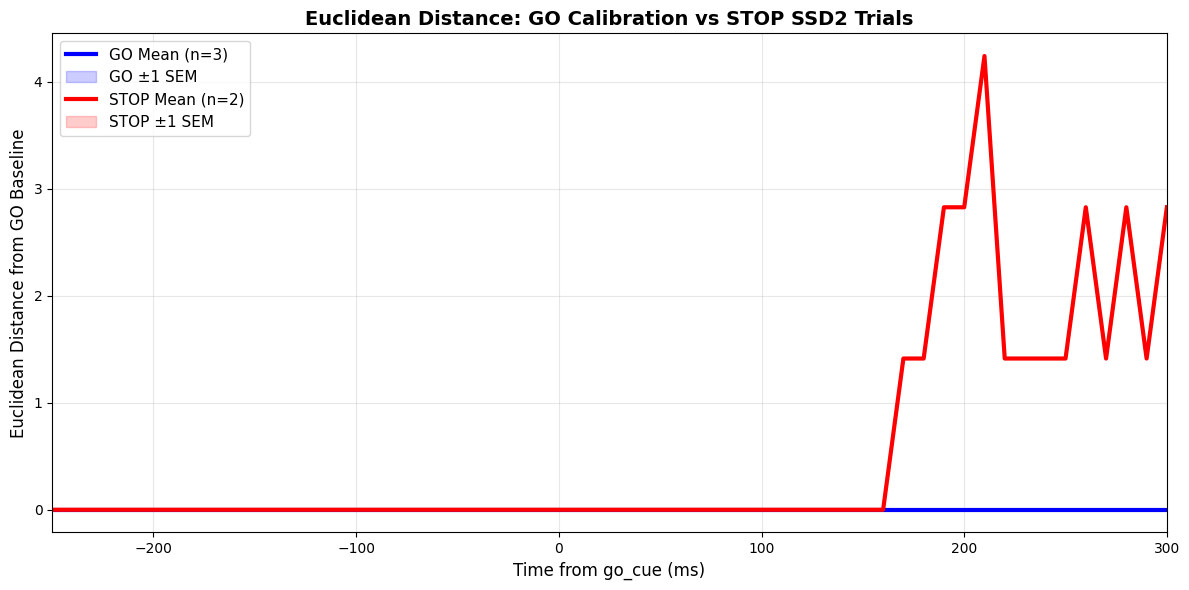


Euclidean Distance Statistics:
  - GO Mean distance (across all time): 0.000
  - GO Distance range (mean): 0.000 - 0.000
  - STOP Mean distance (across all time): 0.530
  - STOP Distance range (mean): 0.000 - 4.243


In [32]:
# Plot Euclidean distances across time with mean and error bars
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot all individual GO calibration trials in light gray
for i in range(euclidean_distances.shape[0]):
        ax.plot(go_binned['bin_centers'], euclidean_distances[i, :], 
                        color='gray', alpha=0.2, linewidth=0.5)

# Compute GO mean and SEM
euclidean_mean = euclidean_distances.mean(axis=0)
euclidean_sem = euclidean_distances.std(axis=0, ddof=1) / np.sqrt(euclidean_distances.shape[0])

# Plot GO mean with error bars
ax.plot(go_binned['bin_centers'], euclidean_mean, 
                color='blue', linewidth=3, label=f'GO Mean (n={euclidean_distances.shape[0]})')
ax.fill_between(go_binned['bin_centers'], 
                                euclidean_mean - euclidean_sem, 
                                euclidean_mean + euclidean_sem,
                                color='blue', alpha=0.2, label='GO ±1 SEM')

# Plot all individual STOP trials in light red
for i in range(euclidean_distances_stop.shape[0]):
        ax.plot(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
                        euclidean_distances_stop[i, :], 
                        color='red', alpha=0.3, linewidth=0.5)

# Compute STOP mean and SEM
euclidean_mean_stop = euclidean_distances_stop.mean(axis=0)
euclidean_sem_stop = euclidean_distances_stop.std(axis=0, ddof=1) / np.sqrt(euclidean_distances_stop.shape[0])

# Plot STOP mean with error bars
ax.plot(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
                euclidean_mean_stop, 
                color='red', linewidth=3, label=f'STOP Mean (n={euclidean_distances_stop.shape[0]})')
ax.fill_between(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
                                euclidean_mean_stop - euclidean_sem_stop, 
                                euclidean_mean_stop + euclidean_sem_stop,
                                color='red', alpha=0.2, label='STOP ±1 SEM')

ax.set_xlabel('Time from go_cue (ms)', fontsize=12)
ax.set_ylabel('Euclidean Distance from GO Baseline', fontsize=12)
ax.set_title('Euclidean Distance: GO Calibration vs STOP SSD2 Trials', 
                         fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(go_binned['bin_centers'][0], go_binned['bin_centers'][-1])

plt.tight_layout()
plt.show()

print(f"\nEuclidean Distance Statistics:")
print(f"  - GO Mean distance (across all time): {euclidean_mean.mean():.3f}")
print(f"  - GO Distance range (mean): {euclidean_mean.min():.3f} - {euclidean_mean.max():.3f}")
print(f"  - STOP Mean distance (across all time): {euclidean_mean_stop.mean():.3f}")
print(f"  - STOP Distance range (mean): {euclidean_mean_stop.min():.3f} - {euclidean_mean_stop.max():.3f}")

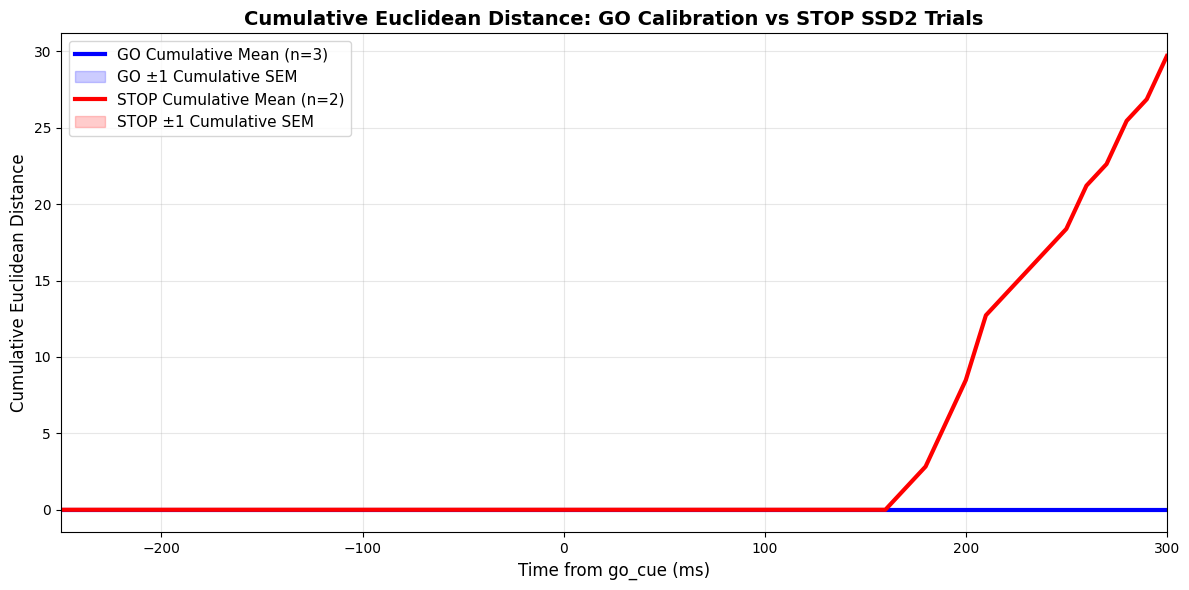


Cumulative Euclidean Distance Statistics:
  - GO Final cumulative distance: 0.0
  - STOP Final cumulative distance: 29.7
  - Difference at final time: 29.7


In [33]:
# Calculate cumulative sum of mean and std for GO and STOP distances
go_cumsum_mean = np.cumsum(euclidean_mean)
go_cumsum_std = np.cumsum(euclidean_sem)

stop_cumsum_mean = np.cumsum(euclidean_mean_stop)
stop_cumsum_std = np.cumsum(euclidean_sem_stop)

# Plot cumulative distances
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot GO cumulative mean with error bars
ax.plot(go_binned['bin_centers'], go_cumsum_mean, 
    color='blue', linewidth=3, label=f'GO Cumulative Mean (n={euclidean_distances.shape[0]})')
ax.fill_between(go_binned['bin_centers'], 
        go_cumsum_mean - go_cumsum_std, 
        go_cumsum_mean + go_cumsum_std,
        color='blue', alpha=0.2, label='GO ±1 Cumulative SEM')

# Plot STOP cumulative mean with error bars
ax.plot(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
    stop_cumsum_mean, 
    color='red', linewidth=3, label=f'STOP Cumulative Mean (n={euclidean_distances_stop.shape[0]})')
ax.fill_between(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
        stop_cumsum_mean - stop_cumsum_std, 
        stop_cumsum_mean + stop_cumsum_std,
        color='red', alpha=0.2, label='STOP ±1 Cumulative SEM')

ax.set_xlabel('Time from go_cue (ms)', fontsize=12)
ax.set_ylabel('Cumulative Euclidean Distance', fontsize=12)
ax.set_title('Cumulative Euclidean Distance: GO Calibration vs STOP SSD2 Trials', 
         fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(go_binned['bin_centers'][0], go_binned['bin_centers'][-1])

plt.tight_layout()
plt.show()

print(f"\nCumulative Euclidean Distance Statistics:")
print(f"  - GO Final cumulative distance: {go_cumsum_mean[-1]:.1f}")
print(f"  - STOP Final cumulative distance: {stop_cumsum_mean[-1]:.1f}")
print(f"  - Difference at final time: {stop_cumsum_mean[-1] - go_cumsum_mean[-1]:.1f}")

# Try simalar approuch to Tzur et al.

We'll use a random sampling approuch to sample from the distances between GO-GO and GO-STOP pairs. 
A large number of samples would give a GO baseline and a GO-STOP divergence.

For each sampled pair we:
1. Chunk the time series to bins of certine size by steps. 
2. For each bin we compute the mean distance and std

Average over all samples to create the GO-GO and GO-STOP signals

In [37]:
## Bootstrap Analysis Parameters

# Set parameters for the bootstrap divergence analysis
BOOTSTRAP_N_SAMPLES = 1000      # Number of random samples to draw
BOOTSTRAP_BIN_SIZE = 50         # Size of bins for chunking time series (ms)
BOOTSTRAP_BIN_STEP = 10         # Step size for sliding window bins (ms)
BOOTSTRAP_RANDOM_SEED = 42      # Random seed for reproducibility

# Analysis window and alignment
BOOTSTRAP_EPOK = [-300, 300]    # Time window [start, end] in ms
BOOTSTRAP_ALIGNMENT = 'go_cue'  # Alignment point: 'go_cue', 'stop_cue', or 'first_relevant_saccade'
BOOTSTRAP_DIRECTION = 180         # Direction: 0 (right) or 180 (left)
BOOTSTRAP_SSD_NUMBER = 2        # SSD number for STOP trials (1-4)

# Display parameters
print("=" * 60)
print("BOOTSTRAP DIVERGENCE ANALYSIS PARAMETERS")
print("=" * 60)
print(f"Number of bootstrap samples: {BOOTSTRAP_N_SAMPLES}")
print(f"Bin size (chunk size): {BOOTSTRAP_BIN_SIZE} ms")
print(f"Bin step (sliding window): {BOOTSTRAP_BIN_STEP} ms")
print(f"Epoch window: {BOOTSTRAP_EPOK} ms")
print(f"Alignment point: {BOOTSTRAP_ALIGNMENT}")
print(f"Direction: {BOOTSTRAP_DIRECTION} ({'Right' if BOOTSTRAP_DIRECTION == 0 else 'Left'})")
print(f"STOP SSD number: {BOOTSTRAP_SSD_NUMBER}")
print(f"Random seed: {BOOTSTRAP_RANDOM_SEED}")
print("=" * 60)

BOOTSTRAP DIVERGENCE ANALYSIS PARAMETERS
Number of bootstrap samples: 1000
Bin size (chunk size): 50 ms
Bin step (sliding window): 10 ms
Epoch window: [-300, 300] ms
Alignment point: go_cue
Direction: 180 (Left)
STOP SSD number: 2
Random seed: 42


In [38]:
## Helper Functions for Bootstrap Analysis

def compute_binned_pairwise_distance(trial1_counts, trial2_counts, bin_size, bin_step, bin_centers):
    """
    Compute binned pairwise distance between two trial trajectories.
    
    For each bin (defined by bin_size and bin_step), compute the mean Euclidean distance
    between the two trial trajectories within that bin.
    
    Parameters:
    -----------
    trial1_counts : np.array, shape (n_neurons, n_timepoints)
        Spike counts for trial 1
    trial2_counts : np.array, shape (n_neurons, n_timepoints)
        Spike counts for trial 2
    bin_size : int
        Size of bins in number of timepoints (not ms)
    bin_step : int
        Step size for sliding window in number of timepoints
    bin_centers : np.array
        Array of bin center times (for reference, not used in computation)
    
    Returns:
    --------
    dict : {
        'mean_distances': np.array of mean distances per bin,
        'std_distances': np.array of std distances per bin,
        'n_bins': number of bins
    }
    """
    n_neurons, n_timepoints = trial1_counts.shape
    
    # Compute Euclidean distance at each timepoint
    # Distance at each timepoint = sqrt(sum((trial1[n,t] - trial2[n,t])^2 over neurons))
    diff = trial1_counts - trial2_counts  # Shape: (n_neurons, n_timepoints)
    pointwise_distances = np.sqrt((diff ** 2).sum(axis=0))  # Shape: (n_timepoints,)
    
    # Chunk into bins with sliding window
    n_bins = (n_timepoints - bin_size) // bin_step + 1
    mean_distances = np.zeros(n_bins)
    std_distances = np.zeros(n_bins)
    
    for i in range(n_bins):
        start_idx = i * bin_step
        end_idx = start_idx + bin_size
        
        # Get distances in this bin
        bin_distances = pointwise_distances[start_idx:end_idx]
        
        # Compute mean and std for this bin
        mean_distances[i] = bin_distances.mean()
        std_distances[i] = bin_distances.std(ddof=1) if len(bin_distances) > 1 else 0.0
    
    return {
        'mean_distances': mean_distances,
        'std_distances': std_distances,
        'n_bins': n_bins
    }


def bootstrap_sample_worker(args):
    """
    Worker function for one bootstrap sample.
    
    Randomly selects one GO-GO pair and one GO-STOP pair, computes binned distances.
    
    Parameters:
    -----------
    args : tuple
        (sample_id, go_counts, stop_counts, bin_size, bin_step, bin_centers, random_seed)
    
    Returns:
    --------
    dict : {
        'sample_id': int,
        'go_go_mean': np.array,
        'go_go_std': np.array,
        'go_stop_mean': np.array,
        'go_stop_std': np.array
    }
    """
    sample_id, go_counts, stop_counts, bin_size, bin_step, bin_centers, random_seed = args
    
    # Set random seed for this sample (ensures reproducibility)
    np.random.seed(random_seed + sample_id)
    
    n_go_trials, n_neurons, n_timepoints = go_counts.shape
    n_stop_trials = stop_counts.shape[0]
    
    # Randomly select two GO trials
    go_pair_idx = np.random.choice(n_go_trials, size=2, replace=False)
    trial1_go = go_counts[go_pair_idx[0]]  # Shape: (n_neurons, n_timepoints)
    trial2_go = go_counts[go_pair_idx[1]]
    
    # Randomly select one GO trial and one STOP trial
    go_idx = np.random.choice(n_go_trials, size=1)[0]
    stop_idx = np.random.choice(n_stop_trials, size=1)[0]
    trial_go = go_counts[go_idx]
    trial_stop = stop_counts[stop_idx]
    
    # Compute binned distances for GO-GO pair
    go_go_result = compute_binned_pairwise_distance(
        trial1_go, trial2_go, bin_size, bin_step, bin_centers
    )
    
    # Compute binned distances for GO-STOP pair
    go_stop_result = compute_binned_pairwise_distance(
        trial_go, trial_stop, bin_size, bin_step, bin_centers
    )
    
    return {
        'sample_id': sample_id,
        'go_go_mean': go_go_result['mean_distances'],
        'go_go_std': go_go_result['std_distances'],
        'go_stop_mean': go_stop_result['mean_distances'],
        'go_stop_std': go_stop_result['std_distances']
    }

print("Bootstrap helper functions defined!")

Bootstrap helper functions defined!


In [39]:
## Run Parallel Bootstrap Analysis

from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

# Bin GO and STOP trials using bootstrap parameters
print(f"Binning trials for bootstrap analysis...")
print(f"  Epoch: {BOOTSTRAP_EPOK} ms")
print(f"  Alignment: {BOOTSTRAP_ALIGNMENT}")
print(f"  Direction: {BOOTSTRAP_DIRECTION} ({'Right' if BOOTSTRAP_DIRECTION == 0 else 'Left'})")
print(f"  SSD Number: {BOOTSTRAP_SSD_NUMBER}")

# Bin GO trials
go_binned_bootstrap = bin_spikes_for_trials(
    data,
    trial_type='GO',
    direction=BOOTSTRAP_DIRECTION,
    success_only=True,
    epok=BOOTSTRAP_EPOK,
    bin_size=bin_size,  # Use original bin_size from cell-18
    bin_step=bin_step,   # Use original bin_step from cell-18
    alignment_point=BOOTSTRAP_ALIGNMENT
)

# Bin STOP trials
stop_binned_bootstrap = bin_spikes_for_trials(
    data,
    trial_type='STOP',
    direction=BOOTSTRAP_DIRECTION,
    ssd_number=BOOTSTRAP_SSD_NUMBER,
    success_only=True,
    epok=BOOTSTRAP_EPOK,
    bin_size=bin_size,
    bin_step=bin_step,
    alignment_point=BOOTSTRAP_ALIGNMENT
)

print(f"\nBinned data shapes:")
print(f"  GO trials: {go_binned_bootstrap['counts'].shape}")
print(f"  STOP trials: {stop_binned_bootstrap['counts'].shape}")

# Convert bin_size and bin_step from ms to number of timepoints
# bin_centers has spacing of bin_step ms
timepoint_spacing_ms = bin_step  # Original bin_step used in bin_spikes_for_trials
bin_size_timepoints = BOOTSTRAP_BIN_SIZE // timepoint_spacing_ms
bin_step_timepoints = BOOTSTRAP_BIN_STEP // timepoint_spacing_ms

print(f"\nConverted parameters:")
print(f"  Bin size: {BOOTSTRAP_BIN_SIZE} ms -> {bin_size_timepoints} timepoints")
print(f"  Bin step: {BOOTSTRAP_BIN_STEP} ms -> {bin_step_timepoints} timepoints")

# Prepare data for parallel processing
go_counts_for_bootstrap = go_binned_bootstrap['counts']  # Shape: (n_go_trials, n_neurons, n_timepoints)
stop_counts_for_bootstrap = stop_binned_bootstrap['counts']  # Shape: (n_stop_trials, n_neurons, n_timepoints)

print(f"\nData shapes for bootstrap:")
print(f"  GO trials: {go_counts_for_bootstrap.shape}")
print(f"  STOP trials: {stop_counts_for_bootstrap.shape}")

# Create arguments for each bootstrap sample
bootstrap_args = [
    (i, go_counts_for_bootstrap, stop_counts_for_bootstrap, 
     bin_size_timepoints, bin_step_timepoints, go_binned_bootstrap['bin_centers'], 
     BOOTSTRAP_RANDOM_SEED)
    for i in range(BOOTSTRAP_N_SAMPLES)
]

# Run bootstrap in parallel
print(f"\nRunning {BOOTSTRAP_N_SAMPLES} bootstrap samples in parallel...")
print(f"Using {mp.cpu_count()} CPU cores")

with ProcessPoolExecutor(max_workers=mp.cpu_count()) as executor:
    bootstrap_results = list(executor.map(bootstrap_sample_worker, bootstrap_args))

print(f"\nBootstrap analysis complete! Collected {len(bootstrap_results)} samples.")
print(f"First result keys: {bootstrap_results[0].keys()}")

Binning trials for bootstrap analysis...
  Epoch: [-300, 300] ms
  Alignment: go_cue
  Direction: 180 (Left)
  SSD Number: 2

Binned data shapes:
  GO trials: (10, 2, 56)
  STOP trials: (2, 2, 56)

Converted parameters:
  Bin size: 50 ms -> 5 timepoints
  Bin step: 10 ms -> 1 timepoints

Data shapes for bootstrap:
  GO trials: (10, 2, 56)
  STOP trials: (2, 2, 56)

Running 1000 bootstrap samples in parallel...
Using 20 CPU cores



Bootstrap analysis complete! Collected 1000 samples.
First result keys: dict_keys(['sample_id', 'go_go_mean', 'go_go_std', 'go_stop_mean', 'go_stop_std'])


In [40]:
## Aggregate Bootstrap Results

# Extract results from all bootstrap samples
n_bins_bootstrap = bootstrap_results[0]['go_go_mean'].shape[0]

# Initialize arrays to store all samples
go_go_means_all = np.zeros((BOOTSTRAP_N_SAMPLES, n_bins_bootstrap))
go_go_stds_all = np.zeros((BOOTSTRAP_N_SAMPLES, n_bins_bootstrap))
go_stop_means_all = np.zeros((BOOTSTRAP_N_SAMPLES, n_bins_bootstrap))
go_stop_stds_all = np.zeros((BOOTSTRAP_N_SAMPLES, n_bins_bootstrap))

# Collect all samples
for i, result in enumerate(bootstrap_results):
    go_go_means_all[i] = result['go_go_mean']
    go_go_stds_all[i] = result['go_go_std']
    go_stop_means_all[i] = result['go_stop_mean']
    go_stop_stds_all[i] = result['go_stop_std']

# Compute average across all bootstrap samples
go_go_mean_signal = go_go_means_all.mean(axis=0)
go_go_sem_signal = go_go_means_all.std(axis=0, ddof=1) / np.sqrt(BOOTSTRAP_N_SAMPLES)

go_stop_mean_signal = go_stop_means_all.mean(axis=0)
go_stop_sem_signal = go_stop_means_all.std(axis=0, ddof=1) / np.sqrt(BOOTSTRAP_N_SAMPLES)

# Create time axis for bootstrap bins
# Each bootstrap bin covers bin_size_timepoints in the original data
# Start from first timepoint and step by bin_step_timepoints
bootstrap_bin_times = np.arange(n_bins_bootstrap) * bin_step_timepoints * timepoint_spacing_ms + go_binned_bootstrap['bin_centers'][0]

print(f"\nBootstrap aggregation complete!")
print(f"  - Number of bootstrap bins: {n_bins_bootstrap}")
print(f"  - GO-GO mean signal shape: {go_go_mean_signal.shape}")
print(f"  - GO-STOP mean signal shape: {go_stop_mean_signal.shape}")
print(f"  - Bootstrap bin times: {bootstrap_bin_times[:5]} ... {bootstrap_bin_times[-5:]}")
print(f"\nSignal statistics:")
print(f"  - GO-GO mean: {go_go_mean_signal.mean():.3f} ± {go_go_sem_signal.mean():.3f}")
print(f"  - GO-STOP mean: {go_stop_mean_signal.mean():.3f} ± {go_stop_sem_signal.mean():.3f}")
print(f"  - Difference: {(go_stop_mean_signal - go_go_mean_signal).mean():.3f}")


Bootstrap aggregation complete!
  - Number of bootstrap bins: 52
  - GO-GO mean signal shape: (52,)
  - GO-STOP mean signal shape: (52,)
  - Bootstrap bin times: [-250 -240 -230 -220 -210] ... [220 230 240 250 260]

Signal statistics:
  - GO-GO mean: 0.000 ± 0.000
  - GO-STOP mean: 0.484 ± 0.000
  - Difference: 0.484


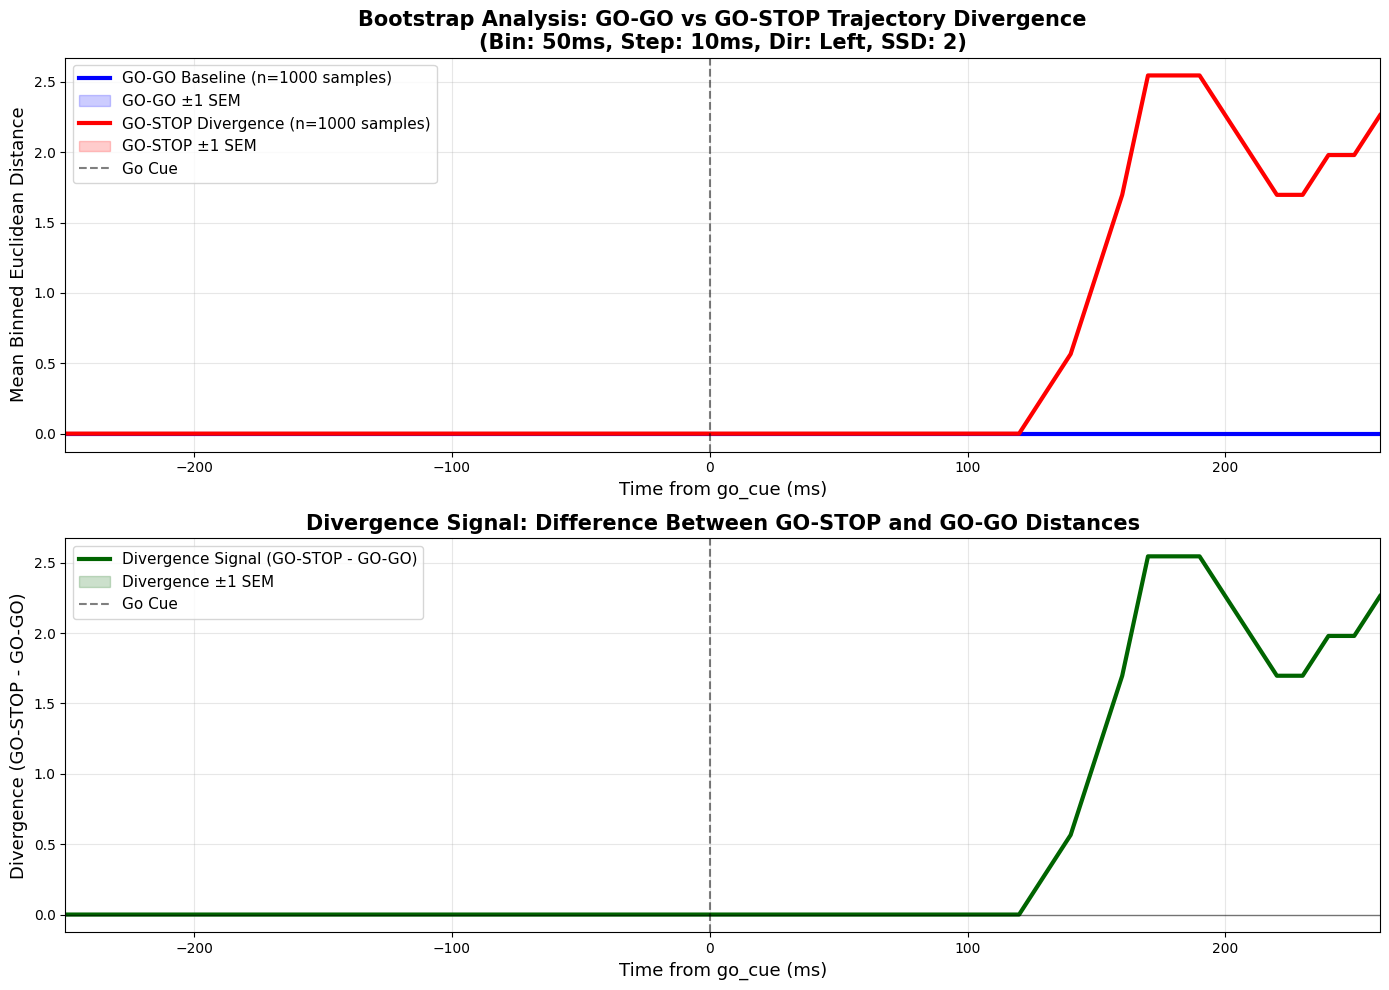


Divergence Signal Statistics:
  - Mean divergence: 0.484
  - Max divergence: 2.546 at t=170 ms
  - Min divergence: 0.000 at t=-250 ms


In [41]:
## Visualize Bootstrap Results

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Determine alignment label for plot
alignment_label = BOOTSTRAP_ALIGNMENT.replace('_', ' ').title()

# ========== Plot 1: Mean Binned Distances ==========
ax1.plot(bootstrap_bin_times, go_go_mean_signal, 
         color='blue', linewidth=3, label=f'GO-GO Baseline (n={BOOTSTRAP_N_SAMPLES} samples)')
ax1.fill_between(bootstrap_bin_times, 
                 go_go_mean_signal - go_go_sem_signal, 
                 go_go_mean_signal + go_go_sem_signal,
                 color='blue', alpha=0.2, label='GO-GO ±1 SEM')

ax1.plot(bootstrap_bin_times, go_stop_mean_signal, 
         color='red', linewidth=3, label=f'GO-STOP Divergence (n={BOOTSTRAP_N_SAMPLES} samples)')
ax1.fill_between(bootstrap_bin_times, 
                 go_stop_mean_signal - go_stop_sem_signal, 
                 go_stop_mean_signal + go_stop_sem_signal,
                 color='red', alpha=0.2, label='GO-STOP ±1 SEM')

ax1.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label=alignment_label)
ax1.set_xlabel(f'Time from {BOOTSTRAP_ALIGNMENT} (ms)', fontsize=13)
ax1.set_ylabel('Mean Binned Euclidean Distance', fontsize=13)
ax1.set_title(f'Bootstrap Analysis: GO-GO vs GO-STOP Trajectory Divergence\n' + 
             f'(Bin: {BOOTSTRAP_BIN_SIZE}ms, Step: {BOOTSTRAP_BIN_STEP}ms, Dir: {"Right" if BOOTSTRAP_DIRECTION == 0 else "Left"}, SSD: {BOOTSTRAP_SSD_NUMBER})', 
             fontsize=15, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(bootstrap_bin_times[0], bootstrap_bin_times[-1])

# ========== Plot 2: Difference Signal (GO-STOP - GO-GO) ==========
difference_signal = go_stop_mean_signal - go_go_mean_signal
difference_sem = np.sqrt(go_go_sem_signal**2 + go_stop_sem_signal**2)  # Propagate errors

ax2.plot(bootstrap_bin_times, difference_signal, 
         color='darkgreen', linewidth=3, label='Divergence Signal (GO-STOP - GO-GO)')
ax2.fill_between(bootstrap_bin_times, 
                 difference_signal - difference_sem, 
                 difference_signal + difference_sem,
                 color='darkgreen', alpha=0.2, label='Divergence ±1 SEM')

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label=alignment_label)
ax2.set_xlabel(f'Time from {BOOTSTRAP_ALIGNMENT} (ms)', fontsize=13)
ax2.set_ylabel('Divergence (GO-STOP - GO-GO)', fontsize=13)
ax2.set_title('Divergence Signal: Difference Between GO-STOP and GO-GO Distances', 
             fontsize=15, fontweight='bold')
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(bootstrap_bin_times[0], bootstrap_bin_times[-1])

plt.tight_layout()
plt.show()

print(f"\nDivergence Signal Statistics:")
print(f"  - Mean divergence: {difference_signal.mean():.3f}")
print(f"  - Max divergence: {difference_signal.max():.3f} at t={bootstrap_bin_times[difference_signal.argmax()]:.0f} ms")
print(f"  - Min divergence: {difference_signal.min():.3f} at t={bootstrap_bin_times[difference_signal.argmin()]:.0f} ms")